<a href="https://colab.research.google.com/github/cylaadhan/FuzzyLogic/blob/main/TAfix1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Library berhasil diimport
✅ Data Standar USM    : 369 baris, kolom: ['Standar', 'Pernyataan Isi Standar', 'Pernyataan Standar Indikator', 'FULL']
✅ Data Matriks LAM   : 75 baris, kolom: ['KRITERIA', 'ELEMEN', 'DESKRIPTOR', 'FULL']
✅ Kolom FULL ditemukan di kedua dataset
✅ Preprocessing selesai
   Teks kosong  → Standar: 0, Matriks: 0
   Teks duplikat → Standar: 0, Matriks: 0

⏳ Memuat model indobenchmark/indobert-base-p1 ...


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

✅ Model IndoBERT berhasil dimuat (device: cpu)

⏳ Menghasilkan embedding Standar USM ...
   Batch 5/24 selesai
   Batch 10/24 selesai
   Batch 15/24 selesai
   Batch 20/24 selesai
✅ Embedding Standar USM : (369, 768)

⏳ Menghasilkan embedding Matriks LAM ...
   Batch 5/5 selesai
✅ Embedding Matriks LAM : (75, 768)

⏳ Menghitung cosine similarity ...
✅ Similarity matrix : (75, 369)  (75 x 369 = 27,675 pasangan)
✅ Total pasangan: 27,675

📋 TOP-10 GLOBAL:
 rank_global  no_teks_matrik  no_teks_standar  skor_similarity
           1              62              350         0.969801
           2              62              292         0.968981
           3              64              359         0.968312
           4              64              350         0.967296
           5              64              364         0.967165
           6              62              364         0.967155
           7              62              359         0.966778
           8              64           

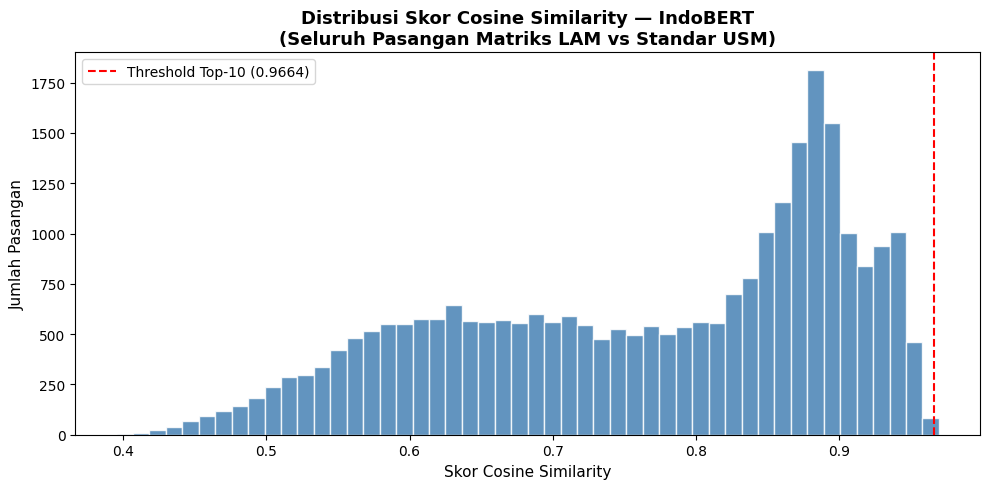

✅ Histogram distribusi disimpan


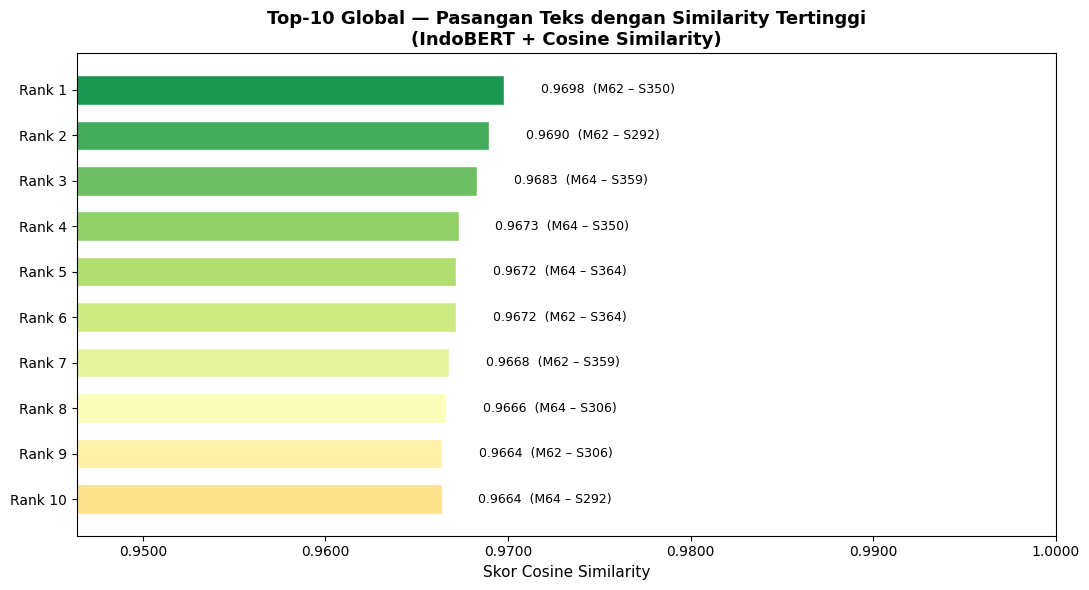

✅ Bar chart Top-10 Global disimpan

🎉 PROSES SELESAI!
   Output utama : hasil_top10_global_indobert.xlsx
   Histogram    : histogram_distribusi_similarity.png
   Bar chart    : barchart_top10_global.png


In [1]:
# ============================================================
# MAPPING MATRIKS LAM INFOKOM vs STANDAR USM
# Metode: IndoBERT + Cosine Similarity + Top-10 Global
# ============================================================

# ── 1. Install Library ───────────────────────────────────────
# Jalankan cell ini sekali, lalu restart runtime jika diminta
# !pip install transformers torch scikit-learn openpyxl pandas numpy matplotlib

# ── 2. Import Library ────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

# ── 3. Upload & Baca Dataset ─────────────────────────────────
# Jika di Google Colab, upload manual lewat file manager ATAU pakai:
# from google.colab import files
# uploaded = files.upload()

# Ubah path sesuai lokasi file di Colab kamu
PATH_STANDAR = "standarF.xlsx"   # ← ganti jika perlu
PATH_MATRIK  = "matrik.xlsx"     # ← ganti jika perlu

df_standar = pd.read_excel(PATH_STANDAR)
df_matrik  = pd.read_excel(PATH_MATRIK)

# Bersihkan nama kolom
df_standar.columns = df_standar.columns.str.strip()
df_matrik.columns  = df_matrik.columns.str.strip()

print(f"✅ Data Standar USM    : {df_standar.shape[0]} baris, kolom: {df_standar.columns.tolist()}")
print(f"✅ Data Matriks LAM   : {df_matrik.shape[0]} baris, kolom: {df_matrik.columns.tolist()}")

# ── 4. Validasi Kolom FULL ───────────────────────────────────
assert 'FULL' in df_standar.columns, "❌ Kolom FULL tidak ditemukan di standarF.xlsx!"
assert 'FULL' in df_matrik.columns,  "❌ Kolom FULL tidak ditemukan di matrik.xlsx!"
print("✅ Kolom FULL ditemukan di kedua dataset")

# ── 5. Ambil Teks Mentah ──────────────────────────────────────
standar_texts_raw = df_standar['FULL'].astype(str).tolist()
matrik_texts_raw  = df_matrik['FULL'].astype(str).tolist()

# ── 6. Preprocessing Ringan ───────────────────────────────────
def preprocess(text):
    text = str(text)
    text = text.replace('&nbsp;', ' ').replace('\xa0', ' ')
    text = text.lower()
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    text = ' '.join(text.split())  # hapus spasi berlebih
    return text.strip()

standar_texts = [preprocess(t) for t in standar_texts_raw]
matrik_texts  = [preprocess(t) for t in matrik_texts_raw]

df_standar['FULL_PREPROCESS'] = standar_texts
df_matrik['FULL_PREPROCESS']  = matrik_texts

print("✅ Preprocessing selesai")

# ── 7. Validasi Pasca Preprocessing ──────────────────────────
kosong_standar = sum(1 for t in standar_texts if not t)
kosong_matrik  = sum(1 for t in matrik_texts  if not t)
duplikat_standar = len(standar_texts) - len(set(standar_texts))
duplikat_matrik  = len(matrik_texts)  - len(set(matrik_texts))

print(f"   Teks kosong  → Standar: {kosong_standar}, Matriks: {kosong_matrik}")
print(f"   Teks duplikat → Standar: {duplikat_standar}, Matriks: {duplikat_matrik}")

# ── 8. Load Model IndoBERT ────────────────────────────────────
MODEL_NAME = "indobenchmark/indobert-base-p1"
print(f"\n⏳ Memuat model {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"✅ Model IndoBERT berhasil dimuat (device: {device})")

# ── 9. Fungsi Embedding IndoBERT ──────────────────────────────
def get_embedding(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        # Ambil token [CLS] sebagai representasi teks
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        if (i // batch_size + 1) % 5 == 0:
            print(f"   Batch {i // batch_size + 1}/{(len(texts) - 1) // batch_size + 1} selesai")
    return np.vstack(all_embeddings)

# ── 10. Generate Embedding ────────────────────────────────────
print("\n⏳ Menghasilkan embedding Standar USM ...")
standar_embeddings = get_embedding(standar_texts)
print(f"✅ Embedding Standar USM : {standar_embeddings.shape}")

print("\n⏳ Menghasilkan embedding Matriks LAM ...")
matrik_embeddings = get_embedding(matrik_texts)
print(f"✅ Embedding Matriks LAM : {matrik_embeddings.shape}")

# ── 11. Hitung Cosine Similarity ──────────────────────────────
print("\n⏳ Menghitung cosine similarity ...")
sim_matrix = cosine_similarity(matrik_embeddings, standar_embeddings)
print(f"✅ Similarity matrix : {sim_matrix.shape}  ({sim_matrix.shape[0]} x {sim_matrix.shape[1]} = {sim_matrix.shape[0] * sim_matrix.shape[1]:,} pasangan)")

# ── 12. Kumpulkan Semua Pasangan ──────────────────────────────
rows = []
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        rows.append({
            'no_teks_matrik': i + 1,
            'no_teks_standar': j + 1,
            'teks_matrik': matrik_texts_raw[i],
            'teks_standar': standar_texts_raw[j],
            'skor_similarity': sim_matrix[i, j]
        })

df_semua = pd.DataFrame(rows)
df_semua_sorted = df_semua.sort_values('skor_similarity', ascending=False).reset_index(drop=True)
print(f"✅ Total pasangan: {len(df_semua_sorted):,}")

# ── 13. Top-10 Global ─────────────────────────────────────────
TOP_K = 10
df_top10 = df_semua_sorted.head(TOP_K).copy()
df_top10.insert(0, 'rank_global', range(1, TOP_K + 1))
df_top10 = df_top10[['rank_global', 'no_teks_matrik', 'no_teks_standar',
                      'teks_matrik', 'teks_standar', 'skor_similarity']]

print("\n📋 TOP-10 GLOBAL:")
print(df_top10[['rank_global', 'no_teks_matrik', 'no_teks_standar', 'skor_similarity']].to_string(index=False))

# Verifikasi urutan
urutan_benar = all(
    df_top10['skor_similarity'].iloc[i] >= df_top10['skor_similarity'].iloc[i+1]
    for i in range(len(df_top10) - 1)
)
print(f"\n✅ Urutan Top-10 Global sudah benar: {urutan_benar}")

# ── 14. Top-10 Lengkap (dengan kolom preprocessing) ──────────
df_top10_lengkap = df_top10.copy()
df_top10_lengkap['teks_matrik_preprocess']  = df_top10['no_teks_matrik'].apply(
    lambda x: matrik_texts[x - 1])
df_top10_lengkap['teks_standar_preprocess'] = df_top10['no_teks_standar'].apply(
    lambda x: standar_texts[x - 1])
df_top10_lengkap['metode'] = 'IndoBERT + Cosine Similarity'
df_top10_lengkap['model']  = 'indobenchmark/indobert-base-p1'

# ── 15. Ringkasan Hasil ───────────────────────────────────────
ringkasan = {
    'metode': 'IndoBERT + Cosine Similarity + Top-10 Global',
    'model': 'indobenchmark/indobert-base-p1',
    'jumlah_data_matrik': len(matrik_texts),
    'jumlah_data_standar': len(standar_texts),
    'jumlah_pasangan_perbandingan': len(matrik_texts) * len(standar_texts),
    'top_k_global': TOP_K,
    'skor_tertinggi_global': round(df_top10['skor_similarity'].max(), 6),
    'skor_terendah_top10_global': round(df_top10['skor_similarity'].min(), 6),
    'rata_rata_top10_global': round(df_top10['skor_similarity'].mean(), 6),
}

df_ringkasan = pd.DataFrame([
    {'Parameter': k, 'Nilai': v} for k, v in ringkasan.items()
])

print("\n📊 RINGKASAN:")
print(df_ringkasan.to_string(index=False))

# ── 16. Simpan ke Excel ───────────────────────────────────────
OUTPUT_FILE = "hasil_top10_global_indobert.xlsx"

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df_top10.to_excel(writer, sheet_name='Top10_Global', index=False)
    df_top10_lengkap.to_excel(writer, sheet_name='Top10_Global_Lengkap', index=False)
    df_semua_sorted.to_excel(writer, sheet_name='Semua_Pasangan', index=False)
    df_ringkasan.to_excel(writer, sheet_name='Ringkasan', index=False)

print(f"\n✅ Hasil disimpan ke: {OUTPUT_FILE}")

# ── 17. Download File (khusus Google Colab) ───────────────────
# Hapus tanda komentar (#) pada baris di bawah jika memakai Google Colab
# from google.colab import files
# files.download(OUTPUT_FILE)

# ── 18. Visualisasi: Histogram Distribusi Skor Similarity ─────
all_scores = df_semua['skor_similarity'].values

plt.figure(figsize=(10, 5))
plt.hist(all_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Distribusi Skor Cosine Similarity — IndoBERT\n(Seluruh Pasangan Matriks LAM vs Standar USM)',
          fontsize=13, fontweight='bold')
plt.xlabel('Skor Cosine Similarity', fontsize=11)
plt.ylabel('Jumlah Pasangan', fontsize=11)
plt.axvline(df_top10['skor_similarity'].min(), color='red', linestyle='--',
            linewidth=1.5, label=f'Threshold Top-10 ({df_top10["skor_similarity"].min():.4f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('histogram_distribusi_similarity.png', dpi=150)
plt.show()
print("✅ Histogram distribusi disimpan")

# ── 19. Visualisasi: Bar Chart Top-10 Global ─────────────────
labels_top10 = [
    f"M{row['no_teks_matrik']} – S{row['no_teks_standar']}"
    for _, row in df_top10.iterrows()
]
scores_top10 = df_top10['skor_similarity'].values

colors = plt.cm.RdYlGn(np.linspace(0.4, 0.9, TOP_K))[::-1]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(TOP_K, 0, -1), scores_top10, color=colors, edgecolor='white', height=0.65)

ax.set_yticks(range(TOP_K, 0, -1))
ax.set_yticklabels([f"Rank {i}" for i in range(1, TOP_K + 1)], fontsize=10)
ax.set_xlabel('Skor Cosine Similarity', fontsize=11)
ax.set_title('Top-10 Global — Pasangan Teks dengan Similarity Tertinggi\n(IndoBERT + Cosine Similarity)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax.set_xlim(min(scores_top10) - 0.02, 1.0)

for i, (bar, score, label) in enumerate(zip(bars, scores_top10, labels_top10)):
    ax.text(score + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}  ({label})", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('barchart_top10_global.png', dpi=150)
plt.show()
print("✅ Bar chart Top-10 Global disimpan")

print("\n" + "="*60)
print("🎉 PROSES SELESAI!")
print(f"   Output utama : {OUTPUT_FILE}")
print(f"   Histogram    : histogram_distribusi_similarity.png")
print(f"   Bar chart    : barchart_top10_global.png")
print("="*60)